# EDA Open-Meteo
Analyse exploratoire de la source B : données météorologiques complémentaires issues de l'API Open-Meteo Archive.

## 0. Imports, chargement et combinaison des 11 CSV

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

# Combinaison des 11 CSV en un seul DataFrame
dfs = []
for fichier in os.listdir("../data/raw/open_meteo_historique/"):
    if fichier.endswith(".csv"):
        df_ville = pd.read_csv(
            f"../data/raw/open_meteo_historique/{fichier}", skiprows=3
        )
        df_ville.columns = [
            "time",
            "wind_direction_10m",
            "cloud_cover",
            "precipitation",
        ]
        df_ville["NomVille"] = fichier.replace(".csv", "")
        dfs.append(df_ville)

df = pd.concat(dfs, ignore_index=True)

# Conversion temporelle
df["time"] = pd.to_datetime(df["time"])
df["Heure"] = df["time"].dt.hour
df["Mois"] = df["time"].dt.month

# Sauvegarde pour notebook 03
df.to_csv("../data/processed/open_meteo_combined.csv", index=False)

print("Dataset combiné et sauvegardé.")
print(f"Lignes : {df.shape[0]} | Colonnes : {df.shape[1]}")

Dataset combiné et sauvegardé.
Lignes : 25608 | Colonnes : 7


## 1. Description - Dimensionnalité

In [2]:
print(f"Lignes    : {df.shape[0]}")
print(f"Colonnes  : {df.shape[1]}")
print()
print("Types de colonnes :")
print(df.dtypes)

Lignes    : 25608
Colonnes  : 7

Types de colonnes :
time                  datetime64[us]
wind_direction_10m             int64
cloud_cover                    int64
precipitation                float64
NomVille                         str
Heure                          int32
Mois                           int32
dtype: object


### Observations - Dimensionnalité
> Le dataset combiné contient 25 608 lignes pour 7 colonnes. Cela correspond exactement à 11 villes × 2328 heures (97 jours × 24h), ce qui confirme que l'API Open-Meteo Archive est complète sans aucun trou temporel. C'est un avantage majeur par rapport à la source GoodAir qui avait des discontinuités liées à l'infrastructure locale.

## 2. Description - Types de variables

In [3]:
qualitatives = ["NomVille"]
continues = ["wind_direction_10m", "cloud_cover", "precipitation"]
discretes = ["Heure", "Mois"]

print("Qualitatives :", qualitatives)
print("Continues    :", continues)
print("Discrètes    :", discretes)

Qualitatives : ['NomVille']
Continues    : ['wind_direction_10m', 'cloud_cover', 'precipitation']
Discrètes    : ['Heure', 'Mois']


### Observations - Types de variables
> Trois catégories de variables. Une seule variable qualitative, NomVille, qui identifie la ville. Trois variables continues qui constituent nos features complémentaires : la direction du vent en degrés, la couverture nuageuse en pourcentage et les précipitations en millimètres. Deux variables discrètes, Heure et Mois, dérivées de la colonne time et qui seront encodées en sin/cos lors de la préparation des données.

## 3. Description - Statistiques descriptives (variables continues)

In [4]:
stats = df[continues].agg(
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        lambda x: x.quantile(0.25),
        lambda x: x.quantile(0.75),
        "max",
    ]
)
stats.index = ["count", "mean", "median", "std", "min", "Q1", "Q3", "max"]
stats.round(2)

# export des statistiques descriptives pour le notebook 03
stats.to_csv("../data/processed/stats_continues_open_meteo.csv", index=True)

### Observations - Statistiques descriptives
- `wind_direction_10m:` couvre l'ensemble des 360 degrés avec une moyenne à 189° (direction Sud). La médiane à 207° et l'écart type élevé de 109° confirment que le vent varie beaucoup en direction sur la période. C'est une variable circulaire qui nécessitera un encodage sin/cos sur une base de 360 dans la préparation des données.
- `cloud_cover` bien répartie entre 0% et 100% avec une moyenne de 49% et une médiane de 45%. L'écart type de 41% indique une forte variabilité. Les valeurs Q1 à 5% et Q3 à 98% montrent que le ciel est soit très dégagé soit très couvert, avec peu de valeurs intermédiaires stables.
- `precipitation:` très fortement asymétrique. La médiane est à 0 mm et le Q3 aussi à 0 mm, ce qui signifie que plus de 75% des heures n'ont aucune précipitation. La moyenne de 0.07 mm est tirée vers le haut par quelques épisodes de pluie intense, avec un maximum de 13.9 mm. Cette distribution justifie une binarisation en production. sera étudiée dans le notebook 03.

## 4. Description - Taux de valeurs NULL par colonne

In [5]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Taux de NULL (%) par colonne :")
print(null_pct.round(2))

Taux de NULL (%) par colonne :
time                  0.0
wind_direction_10m    0.0
cloud_cover           0.0
precipitation         0.0
NomVille              0.0
Heure                 0.0
Mois                  0.0
dtype: float64


### Observations - Valeurs NULL
> Aucune valeur manquante dans l'ensemble du dataset. Les 25 608 lignes sont complètes sur toutes les colonnes. C'est la principale force d'Open-Meteo par rapport à la source GoodAir. Les données issues de modèles météorologiques numériques ne dépendent pas de capteurs physiques qui peuvent tomber en panne. Cette complétude garantit qu'aucune ligne ne sera perdue lors de la fusion avec GoodAir dans le notebook 03.

## 5. Description - Fréquences

In [ ]:
print("Fréquences par NomVille")
print(df["NomVille"].value_counts())
print()
print("Fréquences par Heure")
print(df["Heure"].value_counts().sort_index())
print()
print("Fréquences par Mois")
print(df["Mois"].value_counts().sort_index())

Fréquences par NomVille
NomVille
Bordeaux        2328
Franconville    2328
Lille           2328
Lyon            2328
Marseille       2328
Nantes          2328
Nice            2328
Paris           2328
Rennes          2328
Strasbourg      2328
Toulouse        2328
Name: count, dtype: int64

Fréquences par Heure
Heure
0     1067
1     1067
2     1067
3     1067
4     1067
5     1067
6     1067
7     1067
8     1067
9     1067
10    1067
11    1067
12    1067
13    1067
14    1067
15    1067
16    1067
17    1067
18    1067
19    1067
20    1067
21    1067
22    1067
23    1067
Name: count, dtype: int64

Fréquences par Mois
Mois
3     792
4    7920
5    8184
6    7920
7     792
Name: count, dtype: int64


### Observations - Fréquences
- `Par ville`, toutes les 11 villes ont exactement 2328 mesures. C'est parfaitement équilibré, ce qui confirme l'absence de trous temporels dans cette source. Contrairement à GoodAir où Franconville avait 104 mesures de moins, Open-Meteo traite toutes les villes de façon identique.
- `Par heure`, chaque heure de la journée a exactement 1067 mesures (97 jours × 11 villes). C'est l'opposé de GoodAir où les heures nocturnes étaient sous-représentées à cause des trous temporels lié à notre infrastructure.
- `Par mois` , mars (792) et juillet (792) sont partiels car ils ne couvrent que quelques jours. Avril, mai et juin sont complets avec respectivement 7920, 8184 et 7920 mesures. La légère différence de mai s'explique par ses 31 jours contre 30 pour avril et juin. Cette répartition est cohérente avec la période de collecte GoodAir.

## 6. Visualisation - Distribution (histogrammes)

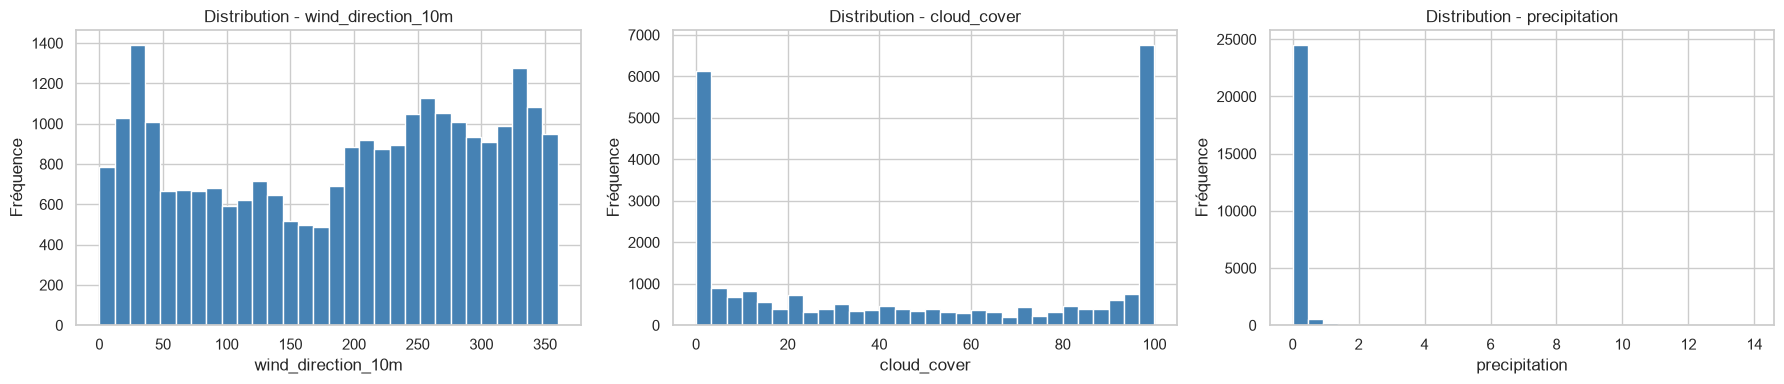

In [8]:
cols_hist = ["wind_direction_10m", "cloud_cover", "precipitation"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, cols_hist):
    df[col].dropna().plot(
        kind="hist", bins=30, ax=ax, color="steelblue", edgecolor="white"
    )
    ax.set_title(f"Distribution - {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

### Observations - Distribution
- **wind_direction_10m** distribution relativement uniforme sur les 360 degrés avec deux pics marqués. Un pic entre 0° et 50° (vents du Nord et Nord-Est) et un second pic entre 300° et 360° (vents du Nord-Ouest). Les directions Sud (90° à 200°) sont moins fréquentes. Cela reflète le régime de vents dominants de l'Ouest et du Nord-Ouest caractéristique de la France au printemps. L'encodage sin/cos est indispensable pour cette variable circulaire.
- **cloud_cover** distribution bimodale très marquée avec deux pics dominants aux extrêmes. Un premier pic à 0% (ciel totalement dégagé) et un second pic à 100% (ciel totalement couvert). Les valeurs intermédiaires entre 10% et 90% sont nettement moins fréquentes. Cela confirme que la couverture nuageuse est rarement partielle. elle est soit absente soit totale.
- **precipitation** distribution extrêmement asymétrique. Plus de 24 000 heures sur 25 608 ont une précipitation de 0 mm. Les quelques valeurs positives s'étalent jusqu'à 13.9 mm mais sont quasi invisibles sur le graphique. Cette variable sera binarisée dans la préparation des données (0 = pas de pluie. 1 = pluie) car sa distribution en continu apporte peu de signal au modèle.

## 7. Comparaison - Boxplot cloud_cover par ville

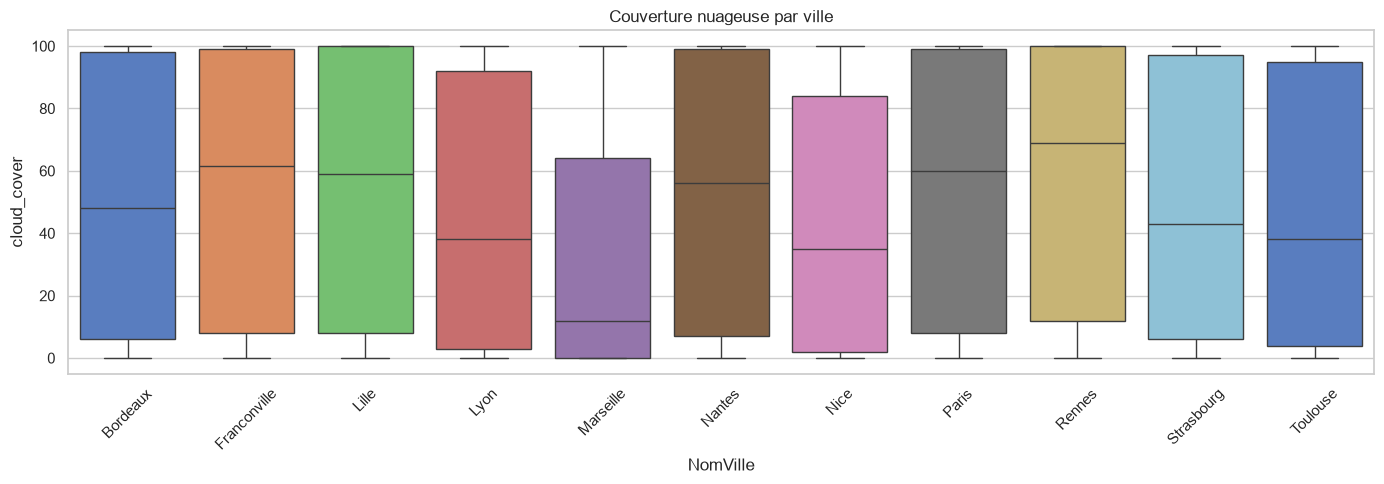

In [4]:
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x="NomVille", y="cloud_cover", palette="muted", hue="NomVille")
plt.title("Couverture nuageuse par ville")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations - Cloud cover par ville
- Les villes du Nord et de l'Est (Lille. Nantes. Paris. Franconville. Strasbourg) ont des boîtes larges s'étalant sur toute la plage 0-100% avec des médianes entre 50% et 65%. Cela traduit un ciel très variable. typique du climat océanique et continental du Nord de la France.
- Nice se distingue nettement avec la médiane la plus basse (environ 35%) et une boîte plus compacte. Le ciel méditerranéen est significativement plus dégagé sur la période. ce qui est cohérent avec les données climatiques connues.
- Marseille a la médiane la plus basse de toutes (environ 10%) avec une boîte très resserrée vers le bas. Confirmant le fort ensoleillement de la région PACA au printemps et en été.
- Lyon et Bordeaux ont des comportements intermédiaires avec des médianes autour de 40% et des boîtes très étendues.
- Aucune valeur aberrante visible, les moustaches atteignent 0% et 100% pour la plupart des villes ce qui est physiquement correct pour cette variable.

## 8. Comparaison - Boxplot precipitation par mois

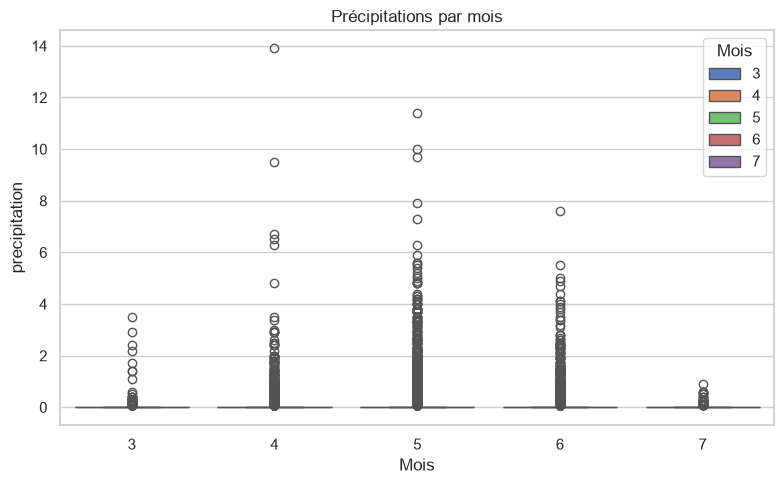

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Mois", y="precipitation", palette="muted", hue="Mois")
plt.title("Précipitations par mois")
plt.tight_layout()
plt.show()

### Observations - Précipitations par mois
- La médiane est à 0 mm pour tous les mois sans exception, ce qui confirme l'observation de l'histogramme. La pluie est un événement rare et ponctuel sur la période.
- Mai est le mois le plus pluvieux avec les outliers les plus nombreux et les plus élevés, dont un pic exceptionnel à 13.9 mm sur une heure. Avril suit avec un pic à 9.5 mm. Juin a moins d'épisodes intenses mais reste actif jusqu'à 7.6 mm.
- Mars et juillet ont très peu d'événements pluvieux, ce qui est cohérent avec leurs couvertures partielles dans notre dataset (seulement quelques jours chacun).
- La quasi totalité des valeurs positives sont des outliers au sens statistique du terme, ce qui renforce la décision de binariser cette variable. Une valeur de 0.1 mm et une valeur de 13.9 mm auront le même signal pour le modèle : il a plu

## 9. Relations - Scatter plot precipitation vs cloud_cover

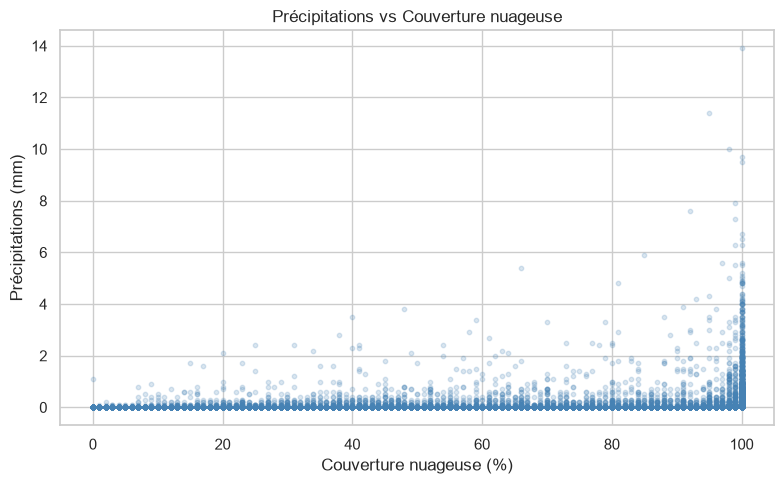

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df["cloud_cover"], df["precipitation"], alpha=0.2, color="steelblue", s=10)
plt.xlabel("Couverture nuageuse (%)")
plt.ylabel("Précipitations (mm)")
plt.title("Précipitations vs Couverture nuageuse")
plt.tight_layout()
plt.show()

### Observations - Relations

la précipitation est une condition météoroloqique qui indique la présence de pluie. La couverture nuageuse est une condition météorologique qui indique la quantité de nuages dans le ciel. La pluie ne peut se produire que si le ciel est couvert de nuages, mais un ciel couvert ne garantit pas nécessairement qu'il pleuvra.

- La relation entre précipitations et couverture nuageuse est claire mais asymétrique. Les précipitations significatives (au dessus de 1 mm) se concentrent presque exclusivement quand la couverture nuageuse est à 100%. La colonne de points très dense à 100% sur l'axe X confirme que la pluie ne tombe quasiment jamais avec un ciel partiellement dégagé.
- En revanche. un ciel à 100% n'implique pas forcément de la pluie. La majorité des points à 100% de couverture nuageuse restent à 0 mm de précipitation. Ce qui signifie que la - couverture nuageuse est une condition nécessaire mais pas suffisante pour la pluie.
- Les quelques points avec des précipitations entre 0 et 40% de couverture nuageuse sont des anomalies rares. probablement des orages locaux ou des erreurs du modèle météo numérique.
- **Conclusion :** cloud_cover et precipitation sont corrélées mais pas redondantes. Les deux apportent une information complémentaire au modèle. On les conserve toutes les deux.

## 10. Distribution temporelle - Direction du vent moyenne par heure

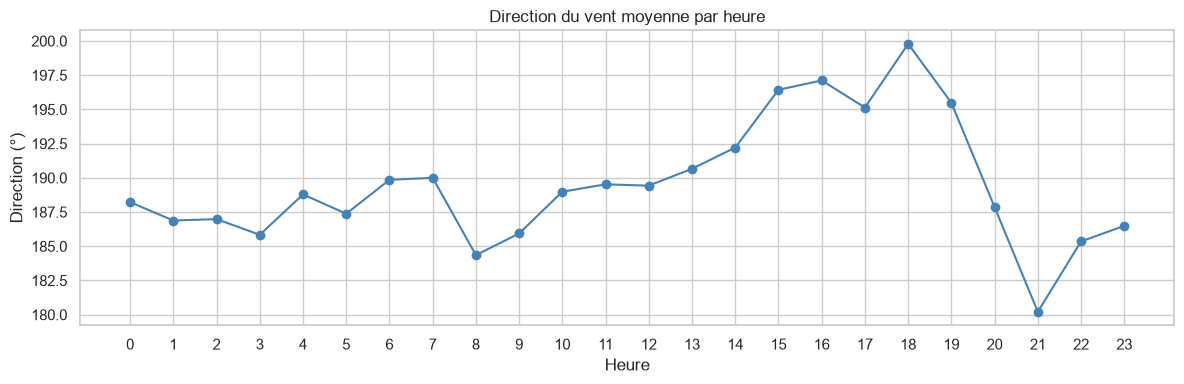

In [15]:
wind_by_hour = df.groupby("Heure")["wind_direction_10m"].mean()

plt.figure(figsize=(12, 4))
wind_by_hour.plot(kind="line", marker="o", color="steelblue")
plt.title("Direction du vent moyenne par heure")
plt.xlabel("Heure")
plt.ylabel("Direction (°)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### Observations - Distribution temporelle
- La direction du vent moyenne oscille entre 180° et 200° sur toute la journée, ce qui correspond à des vents dominants du Sud sur la moyenne de toutes les villes. La variation est faible (moins de 20° d'écart entre le minimum et le maximum) ce qui indique que la direction moyenne est relativement stable au cours de la journée.
- Un pattern diurne est visible. La direction tourne progressivement vers le Sud-Sud-Ouest en fin d'après-midi avec un pic à 18h (199°) avant de revenir vers le Sud en soirée. Ce comportement est typique des brises thermiques qui s'établissent en journée sous l'effet du chauffage solaire.
- Le creux à 21h (180°, plein Sud) est notable mais peut être lié à des effets locaux de quelques villes spécifiques qui tirent la moyenne vers le bas à cette heure.
- Point important : cette courbe représente une moyenne sur 11 villes très différentes géographiquement. Elle masque la forte variabilité inter-ville que l'on a observée dans les statistiques descriptives (écart type de 109°). La direction du vent par ville sera beaucoup plus informative pour le modèle que la moyenne globale.

## 11. Composition - Répartition des directions de vent par ville

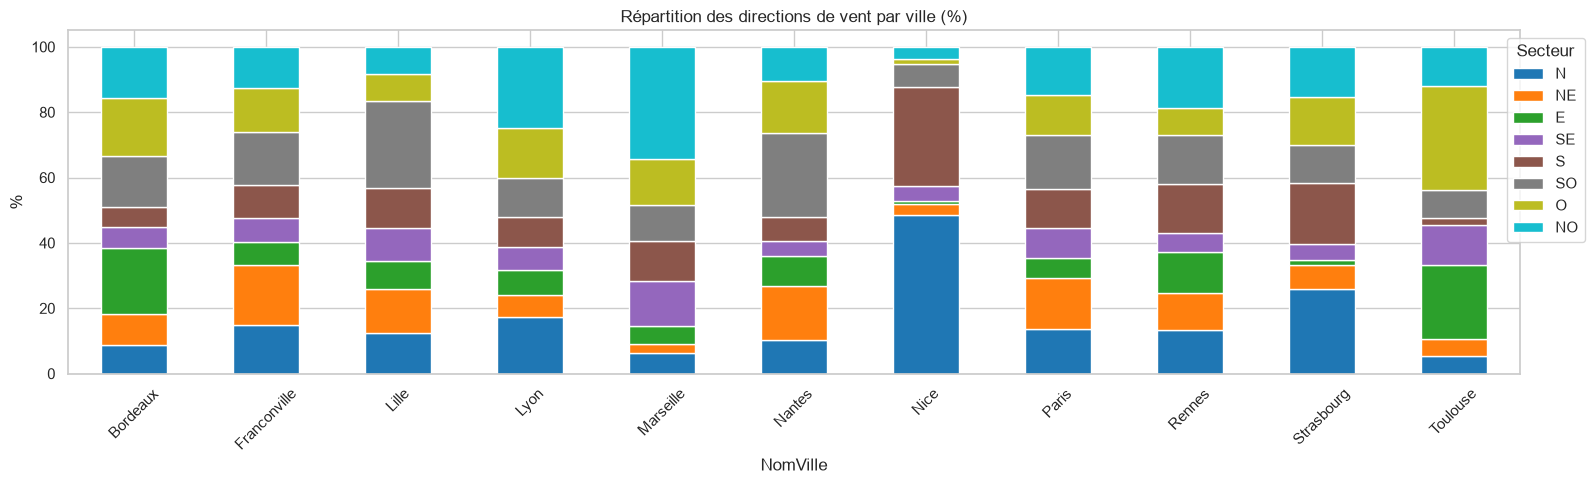

In [ ]:
# Discrétisation de la direction du vent en 8 secteurs
bins = [0, 45, 90, 135, 180, 225, 270, 315, 360] # indique les limites des secteurs de vent en degrés
labels = ["N", "NE", "E", "SE", "S", "SO", "O", "NO"]
df["wind_sector"] = pd.cut(df["wind_direction_10m"], bins=bins, labels=labels)

wind_comp = (
    df.groupby(["NomVille", "wind_sector"], observed=True).size().unstack().fillna(0)
)
wind_comp_pct = wind_comp.div(wind_comp.sum(axis=1), axis=0) * 100

wind_comp_pct.plot(
    kind="bar", stacked=True, figsize=(16, 5), colormap="tab10", edgecolor="white"
)
plt.title("Répartition des directions de vent par ville (%)")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.legend(title="Secteur", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### Observations - Composition
- Les profils de vent sont très différents selon les villes, ce qui confirme que NomVille et wind_direction_10m apportent des informations complémentaires au modèle.
- Nice se distingue radicalement avec environ 50% de vents du Nord (secteur N en bleu). Ce comportement est caractéristique du mistral et de la tramontane qui balaient la côte méditerranéenne du Nord vers le Sud. C'est cohérent avec la géographie locale.
- Marseille a un profil dominé par les secteurs S et SO, avec très peu de vents du Nord. Une des distributions les plus déséquilibrées de toutes les villes.
- Bordeaux, Nantes et Rennes ont des profils diversifiés avec une dominance des secteurs O et NO. ce qui reflète leur exposition aux vents atlantiques venant de l'Ouest.
- Strasbourg et Lyon ont des profils plus équilibrés avec une présence notable des secteurs N et NO. Le relief alpin et vosgien influence les couloirs de vent dans ces régions.
- Paris et Franconville ont des profils similaires avec une répartition assez équilibrée entre N, SO et O.
- **Conclusion :** la direction du vent varie fortement d'une ville à l'autre et reflète la géographie de chaque région. Combinée avec NomVille dans le modèle, cette variable apporte une information physique pertinente sur la dispersion des polluants.

## 12. Matrice de corrélation (variables continues)

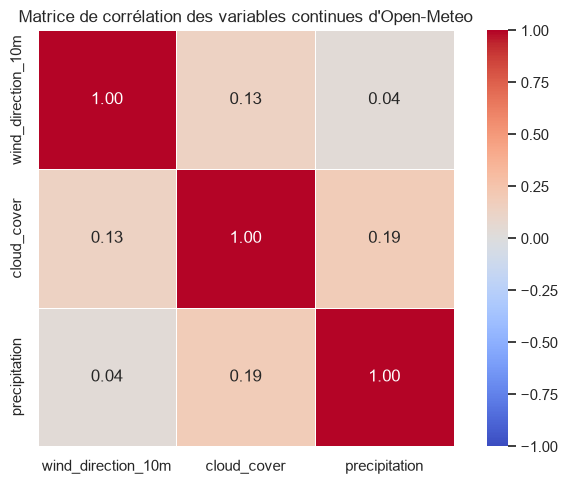

In [18]:
corr = df[continues].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title("Matrice de corrélation des variables continues d'Open-Meteo")
plt.tight_layout()
plt.show()

### Observations - Corrélations

> Les trois variables Open-Meteo sont quasi indépendantes entre elles. Les corrélations sont toutes très faibles.

- cloud_cover et precipitation ont la corrélation la plus élevée du groupe (0.19). ce qui est cohérent avec le scatter plot précédent. la pluie nécessite des nuages mais les nuages ne suffisent pas à provoquer la pluie.
- wind_direction_10m et cloud_cover (0.13) ainsi que wind_direction_10m et precipitation (0.04) sont pratiquement non corrélées. La direction du vent est indépendante des conditions de précipitation sur notre période.
- **Conclusion:** l'absence de multicolinéarité entre ces trois variables est une excellente nouvelle pour le modèle. Chacune apporte une information distincte et indépendante. Combinées aux variables GoodAir dans le notebook 03. elles enrichiront les features sans créer de redondance.

## 13. Synthèse générale - EDA Open-Meteo

**Points clés à retenir pour la suite :**

- Dataset parfaitement complet. 25 608 lignes sans aucun trou temporel ni valeur manquante. Un avantage majeur par rapport à GoodAir.
- Toutes les villes ont exactement 2328 mesures. la source est parfaitement équilibrée.
- La couverture nuageuse est bimodale (0% ou 100%). la précipitation est quasi toujours à 0 mm. la direction du vent varie fortement selon les villes.
- Les trois variables sont quasi indépendantes entre elles. pas de multicolinéarité à craindre.

**Variables avec NULL à surveiller :**

- Aucune. Les trois variables sont complètes à 100%. Aucune imputation nécessaire dans la préparation des données.

**Outliers détectés :**

- precipitation : des valeurs jusqu'à 13.9 mm qui sont statistiquement des outliers mais physiquement légitimes (épisodes pluvieux intenses). Pas de winsorisation prévue car la binarisation (0/1) neutralisera leur impact.
- cloud_cover et wind_direction_10m : aucun outlier. les valeurs couvrent leur plage physique naturelle (0 à 100% et 0° à 360°).

**Features prometteuses pour le modèle :**

- `cloud_cover` : forte variabilité inter-villes et signal physique clair sur la formation des polluants photochimiques.
- `wind_direction_10m` : profils très différents selon les villes. information complémentaire à VitesseVent déjà dans GoodAir. Encodage sin/cos sur 360° obligatoire.
- `precipitation` : sera binarisée (0/1) car sa distribution en continu apporte peu de signal. Son effet "lavage de l'air" est un prédicteur physique reconnu.